<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #2f7681ff;
            overflow:hidden;
            font-weight:500">Bank Marketing Campaign Prediction</div>

****

# Table Of Content

1. Table of Content

2. Business Problem Understanding

3. Problem Statement

4. Analytic Approach

5. Metric Evaluation

6. EDA

7. Feature Engineering

8. Modelling

9. Model Evaluation & Business Impact

10. Overview

11. Recommendations

12. Conclusion

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 1. Business Problem Understanding

></div>
****

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 1.1 Context

></div>
****

The banking industry operates in a highly competitive and dynamic environment, where maintaining and expanding market share remains a critical challenge. One of the key financial products that reflects a bank’s liquidity stability and overall financial health is the **term deposit**. 

Term deposits not only secure customers’ funds for a fixed period but also serve as a primary funding source that enables banks to extend credit and support lending activities. Consequently, increasing the number of customers who subscribe to term deposits has become a strategic priority for banking institutions.

To achieve this objective, banks utilize various marketing channels, with telemarketing being one of the most widely implemented approaches. Through telemarketing campaigns, banks proactively offer deposit products to both existing and prospective customers. However, conventional strategies that contact customers indiscriminately or without clear prioritization often lead to inefficiencies. Such approaches result in unnecessary operational costs, including telecommunication expenses and marketing workforce allocation, while potentially causing customer dissatisfaction due to irrelevant outreach.

Therefore, the central challenge lies in identifying customers who are most likely to respond positively to a term deposit offer. Developing a predictive approach to effectively target high-potential customers is essential to improve campaign efficiency, reduce operational costs, and maximize conversion rates.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 1.2 Identification Stakeholders

></div>
****

**1. Marketing Team:**
Use predicted probabilities to prioritize high-potential customers and improve campaign efficiency.

**2. Sales & Telemarketing:**
Focus on customers with prior successful interactions and strong financial profiles, and adjust the probability threshold based on campaign objectives (conversion vs cost efficiency).

**3. Product Management:**
Develop targeted deposit strategies based on key drivers such as previous campaign success and customer balance.

**4. Business Management:**
Leverage model insights and cost evaluation results to reduce operational costs, improve time efficiency, and maximize overall campaign profitability.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 2. Problem Statement

></div>
****

Based on the identified business challenges and stakeholder needs, the main problem to be addressed in this Bank Marketing Campaign case study is:

"How can a machine learning model be developed to accurately predict whether a customer will subscribe to a term deposit, enabling the bank to improve the effectiveness and efficiency of its telemarketing campaign by leveraging historical customer data to estimate subscription probability?"

The inability to accurately predict customer responses leads to low campaign efficiency, as reflected in a small conversion rate compared to the total number of calls made.

The performance of the predictive model can be evaluated using classification metrics such as:

- Precision

- Recall

- F1-score

- Confusion Matrix

**Main Purpose**

The primary objective of this study is to develop a classification model capable of predicting the probability that a customer will subscribe to a term deposit.

More specifically, the model is expected to:

**1. Improve campaign cost efficiency :** By reducing unnecessary calls to customers who are unlikely to subscribe, thereby minimizing operational costs associated with false positives.

**2. Increase deposit conversion rate :** By effectively identifying and prioritizing high-potential customers, ensuring that true potential subscribers are contacted (maintaining strong recall performance).

**3. Provide actionable customer insights :** By identifying the most influential features (such as balance, age, poutcome, and other campaign-related variables) that drive subscription decisions, supporting data-driven marketing strategies.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 3. Analytic Approcach

></div>
****


The problem is formulated as a binary classification task, where the objective is to predict whether a customer will subscribe to a term deposit.

Target variable:

- 0 : Customer does not Deposit

- 1 : Customer Depost

Since the target variable consists of two classes (subscribe or not subscribe), binary classification is the appropriate modeling framework.

Several classification models were evaluated and compared using cros -validation, with performance measured primarily through the F1-score to balance precision and recall. The best-performing model, XGBoost, was selected and further optimized through hyperparameter tuning.

The final model was evaluated using classification metrics and a confusion matrix, and its business impact was assessed through cost evaluation to ensure alignment with marketing efficiency objectives.




<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 4. Metric Evaluation

></div>
****

In [1]:
# Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer
import category_encoders as ce
from scipy.stats import chi2_contingency

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)


In [2]:
# Read Data

df=pd.read_csv('data_bank_marketing_campaign.csv')
display(df.head(), df.tail())

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no
7812,60,retired,1588,no,no,cellular,oct,1,-1,unknown,yes


<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 5. EDA

></div>
**** 

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 5.1 Explore Data

></div>
****


In [3]:
df

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 671.6 KB


**Data Dictionary**

| **No** | **Nama Variabel** | **Tipe Data**           | **Deskripsi**                                                             | **Peran**   |
| -- | ------------- | ------------------- | --------------------------------------------------------------------- | ------- |
| 1  | `age`           | Numerik             | Usia nasabah dalam tahun                                              | Feature |
| 2  | `job`           | Kategorikal         | Jenis pekerjaan nasabah                                               | Feature |
| 3  | `balance`       | Numerik             | Rata-rata saldo tahunan nasabah                                       | Feature |
| 4  | `housing`       | Kategorikal (Biner) | Status kepemilikan kredit rumah (Yes/No)                              | Feature |
| 5  | `loan`          | Kategorikal (Biner) | Status kepemilikan pinjaman pribadi (Yes/No)                          | Feature |
| 6  | `contact`       | Kategorikal         | Jenis komunikasi terakhir yang digunakan untuk menghubungi nasabah    | Feature |
| 7  | `month`         | Kategorikal         | Bulan terakhir nasabah dihubungi                                      | Feature |
| 8  | `campaign`      | Numerik             | Jumlah kontak yang dilakukan selama campaign                          | Feature |
| 9  | `pdays`         | Numerik             | Jumlah hari sejak nasabah terakhir dihubungi pada campaign sebelumnya | Feature |
| 10 | `poutcome`      | Kategorikal         | Hasil dari campaign pemasaran sebelumnya                              | Feature |
| 11 | `deposit`       | Kategorikal (Biner) | Status apakah nasabah melakukan deposit (0 = Tidak, 1 = Ya)           | Target  |


In [5]:
target_col = "deposit"

cat_cols = df.drop(columns=target_col).select_dtypes(include="object").columns
print("Categorical Features:")
print(cat_cols)
print()
num_cols = df.drop(columns=target_col).select_dtypes(include="number").columns
print("Numerical Features:")
print(num_cols)

Categorical Features:
Index(['job', 'housing', 'loan', 'contact', 'month', 'poutcome'], dtype='str')

Numerical Features:
Index(['age', 'balance', 'campaign', 'pdays'], dtype='str')


**NOTE :**
    
> **Data Numerical**

 **1. Discrete:**
- `campaign`

- `pdays` : In this column, there are values equal to -1. The value -1 indicates that the customer was not contacted during the previous campaign period.

    To prevent the model from misinterpreting this value as a negative numerical relationship, the value -1 will be replaced with 0. 
    
    This transformation ensures that the variable remains numerically consistent and does not introduce misleading information into the modeling process.
        
**2. Continue:**

- `age`

- `balance`
     
> **Data Categorical**
 
**1. Ordinal:**  0
      
**2. Nominal :**

- `job` : This category will be retained in the modeling process as a separate class. The unknown label represents customers whose occupational information was not completely recorded during data collection.

- `housing`: 

- `loan`: 

- `contact` : There is also a category labeled unknown. This category will be preserved and treated as a valid class in the modeling process. The unknown label indicates that the communication method was not properly recorded.

- `month`

- `poutcome`: In this column, there are categories labeled unknown and other. These categories will be retained for the following reasons:

1. The unknown category represents customers who were not contacted during the previous marketing campaign.

2. The other category represents customers who were previously contacted but did not provide a definitive response, such as requesting a callback at a later time or cases where the call was unsuccessful.

Since these categories contain meaningful business information, they will be maintained in the dataset.

- `deposit` (target variable)

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight</b>
    <li> In `p days` column, there are values equal to -1. The value -1 indicates that the customer was not contacted during the previous campaign period.</li>
    <li> To prevent the model from misinterpreting this value as a negative numerical relationship, the value -1 will be replaced with 0. </li> 
    <li>In summary, the `pdays` column requires adjustment before modeling. After handling this transformation, all categorical variables requiring encoding will be processed accordingly. Once preprocessing is completed, the dataset will be ready for model development.</li>

In [6]:
# change pdays colum from -1 to 0 
df = df.replace(-1,0)

In [7]:
#check value -1 is still in pdays column
df.sort_values('pdays')['pdays'].unique()[:5]

array([0, 1, 2, 4, 5])

In [8]:
#count column and rows 
df.shape

(7813, 11)

In [9]:
# melihat junlah data unique di setiap kolom
# Kolom, Jumlah Unique Values dan Contoh Unique Values

pd.set_option('display.max_rows',200)
pd.set_option('display.max_columns',30)
pd.set_option('display.max_colwidth',None)

def unique_data(df):
    data_unique = pd.DataFrame()
    data_unique['Columns'] = df.columns
    data_unique['Unique Count'] = [df[col].nunique() for col in (df.columns)]
    data_unique['Unique'] = [df[col].unique()[:5] for col in (df.columns)]  
    return data_unique
unique_data(df)

,Columns,Unique Count,Unique
0,age,75,"[55, 39, 51, 38, 36]"
1,job,12,"[admin., self-employed, services, housemaid, technician]"
2,balance,3152,"[1662, -3058, 3025, -87, 205]"
3,housing,2,"[no, yes]"
4,loan,2,"[no, yes]"
5,contact,3,"[cellular, telephone, unknown]"
6,month,12,"[jun, apr, may, nov, jan]"
7,campaign,32,"[2, 3, 1, 4, 5]"
8,pdays,422,"[0, 352, 21, 91, 186]"
9,poutcome,4,"[unknown, other, failure, success]"


In [10]:
# mengganti data pada kolom pdays dari -1 ke 0
df = df.replace(-1,0)

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 5.2 Missing Values Check

></div>
****

In [11]:
df.isna().sum()

age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

pada data ini tidak ada missing values, sehingga tidak perlu melakukan inputting missing values

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 5.3 Duplicated Data

></div>
****

In [12]:
# duplicate cross check
df.duplicated().sum()

np.int64(8)

In [13]:
# detele duplicated data
df.drop_duplicates(inplace=True)

In [14]:
print('Descriptive Stats for Number')
display(df.describe(include='number'))
print('Descriptive Stats for Object')
display(df.describe(include='object'))

Descriptive Stats for Number


,age,balance,campaign,pdays
count,7805.000000,7805.000000,7805.000000,7805.000000
mean,41.257783,1513.969250,2.520564,52.206534
std,11.922833,3090.508435,2.728204,107.754164
min,18.000000,-6847.000000,1.000000,0.000000
25%,32.000000,128.000000,1.000000,0.000000
50%,39.000000,550.000000,2.000000,0.000000
75%,49.000000,1685.000000,3.000000,41.000000
max,95.000000,66653.000000,63.000000,854.000000


Descriptive Stats for Object


,job,housing,loan,contact,month,poutcome,deposit
count,7805,7805,7805,7805,7805,7805,7805
unique,12,2,2,3,12,4,2
top,management,no,no,cellular,may,unknown,no
freq,1789,4136,6781,5623,1973,5811,4075


In [15]:
#count column and rows 
df.shape

(7805, 11)

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 5.4 Data Visulization

></div>
****

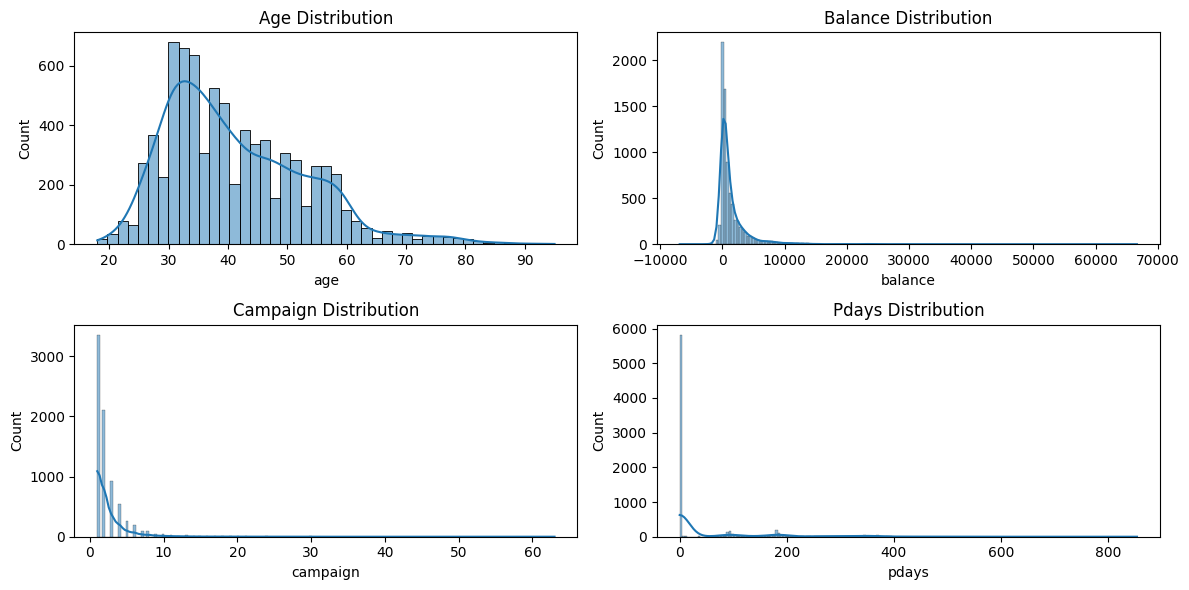

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

sns.histplot(df['age'], ax=axes[0,0], kde=True)
sns.histplot(df['balance'], ax=axes[0,1], kde=True)
sns.histplot(df['campaign'], ax=axes[1,0], kde=True)
sns.histplot(df['pdays'], ax=axes[1,1], kde=True)

axes[0,0].set_title('Age Distribution')
axes[0,1].set_title('Balance Distribution')
axes[1,0].set_title('Campaign Distribution')
axes[1,1].set_title('Pdays Distribution')

plt.tight_layout()
plt.show()

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight</b>
    <li><b>Skewness:</b> Most customers are concentrated in the lower range of balance, campaign frequency, and pdays, indicating strong right-skewed distributions. This suggests that the majority of customers have relatively low balances and are contacted only a few times, while a small group exhibits extremely high values.</li></d>
    <li><b>Outliers:</b> Due to the skewed distributions, several variables (especially <i>balance</i>, <i>campaign</i>, and <i>pdays</i>) contain noticeable outliers. These extreme values may represent high-value customers or unusual campaign patterns and should be carefully examined to determine whether they reflect valid business cases or data anomalies.</li>
</blockquote>

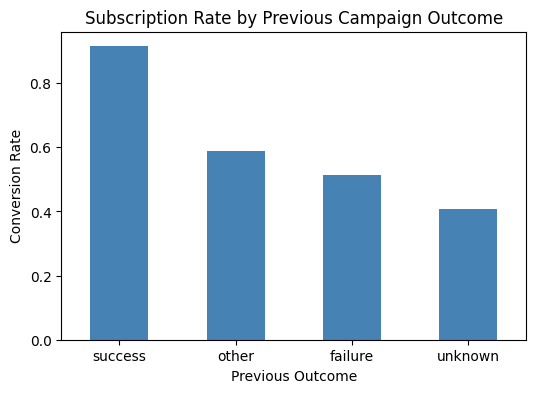

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate conversion rate
conversion_poutcome = (
    df.groupby('poutcome')['deposit']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

conversion_poutcome['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(6,4),
    color='steelblue'
)

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.ylabel('Conversion Rate')
plt.xlabel('Previous Outcome')
plt.xticks(rotation=0)
plt.show()

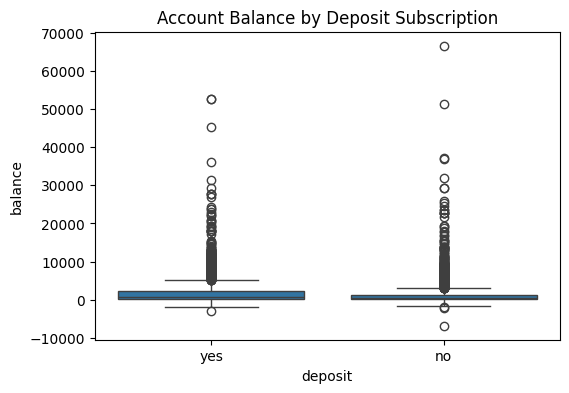

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='deposit', y='balance')
plt.title('Account Balance by Deposit Subscription')
plt.show()

**Campaign Frequency vs Conversion**

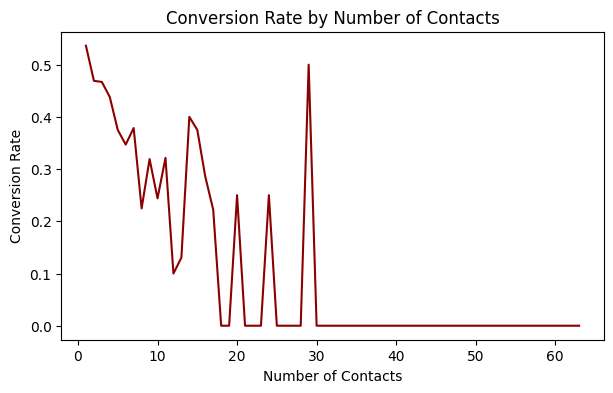

In [76]:
campaign_conv = (
    df.groupby('campaign')['deposit']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

campaign_conv['yes'].plot(figsize=(7,4), color='darkred')
plt.title('Conversion Rate by Number of Contacts')
plt.ylabel('Conversion Rate')
plt.xlabel('Number of Contacts')
plt.show()

<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;">
<ul>Insights:</ul>
<li><b>Conversion rate declines as contact frequency increases.</li>
<li><b>Excessive outreach reduces effectiveness, clear evidence of campaign fatigue.</li>
</ul>
</blockquote>




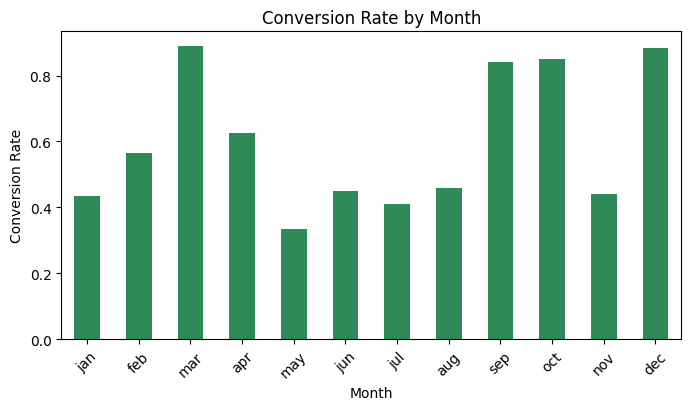

In [78]:
# Define month order
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_conv = (
    df.groupby('month')['deposit']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Reindex sesuai urutan bulan
month_conv = month_conv.reindex(month_order)

# Plot
month_conv['yes'].plot(
    kind='bar',
    figsize=(8,4),
    color='seagreen'
)

plt.title('Conversion Rate by Month')
plt.ylabel('Conversion Rate')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>Higher conversion rates are observed in March, June, September, and October, suggesting strong seasonal opportunities.</li><br>



In [18]:
#Cek Distribusi Data dengan Normal Test
numerical = df.select_dtypes(include='number')
from scipy.stats import normaltest

for i in numerical.columns :
    stats, p_val = normaltest(numerical[i])
    if p_val >= 0.05 :
        print (f"{i} normal distribution")
    else :
        print (f"{i} not normal distribution")

age not normal distribution
balance not normal distribution
campaign not normal distribution
pdays not normal distribution


<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;">
<ul>
<li><b>H₀:</b> The data follows a normal distribution.</li>
<li><b>H₁:</b> The data does not follow a normal distribution.</li>
</ul>
</blockquote>

Result:</b> The normality test indicates that all examined numerical features (age, balance, campaign, and pdays) do not follow a normal distribution (p-value &lt; 0.05).  

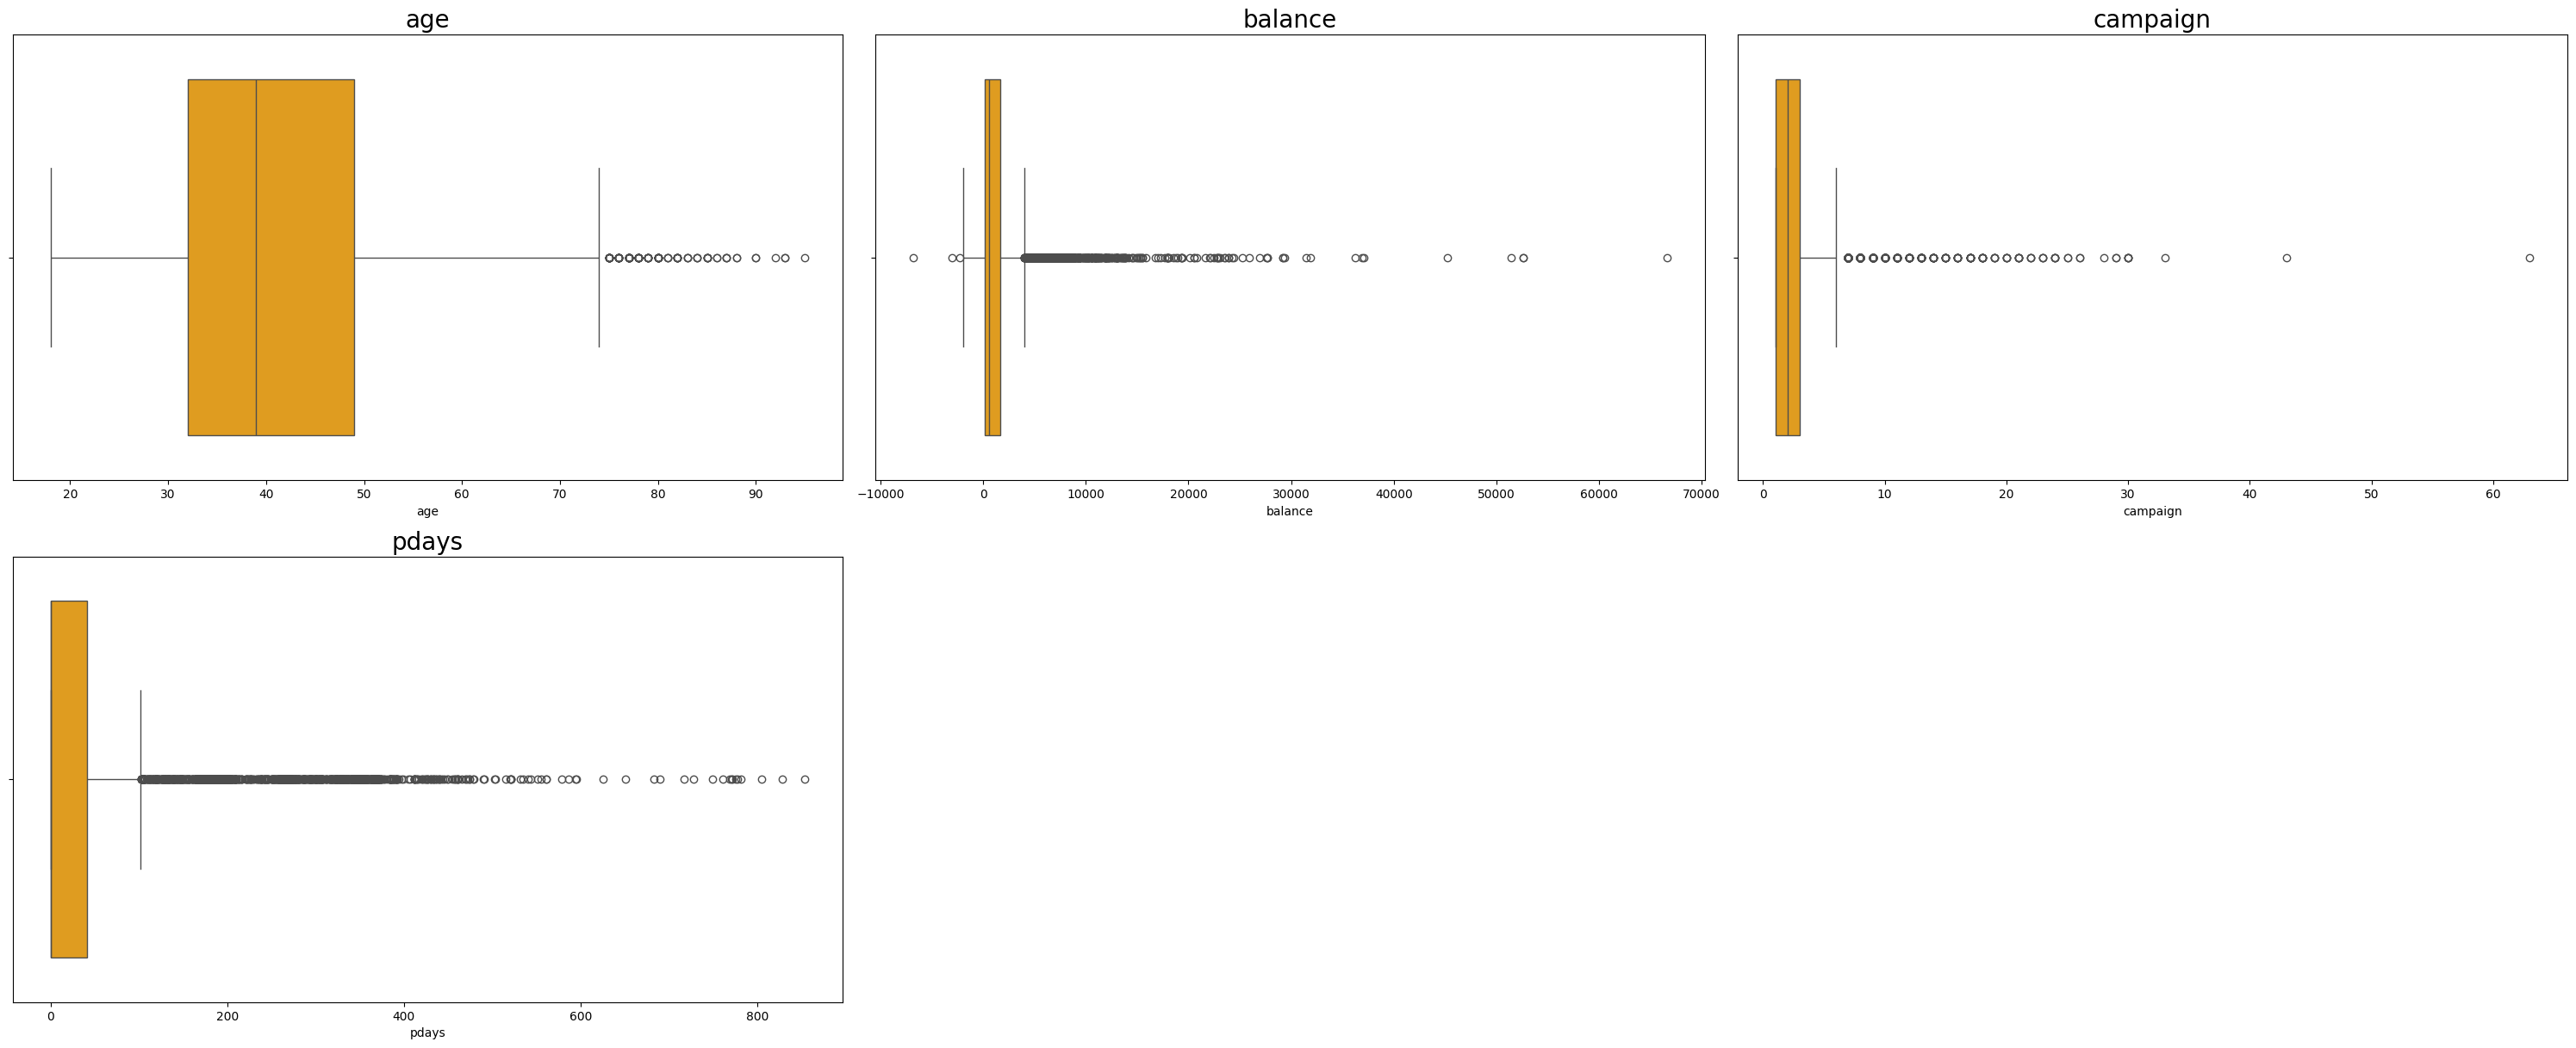

In [19]:
plt.figure(figsize=(30, 30))
plotnumber = 1
num_features = df.select_dtypes(include='number').columns

for feature in num_features:
    ax = plt.subplot(5, 3, plotnumber)
    sns.boxplot(data=df,x=feature,color='orange')
    plt.title(feature, fontsize=20)
    plotnumber += 1
    plt.tight_layout()

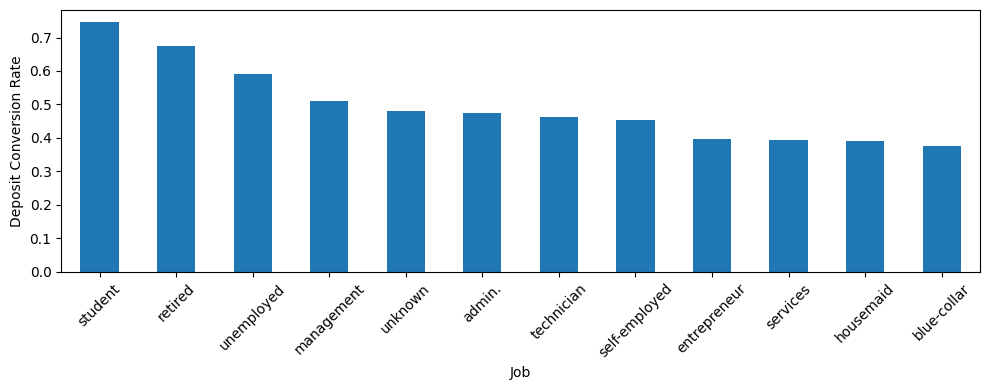

In [20]:
conversion = (
    df.groupby('job')['deposit']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values(ascending=False)
)

ax = conversion.plot(kind='bar', figsize=(10,4))

plt.xlabel('Job')
plt.ylabel('Deposit Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

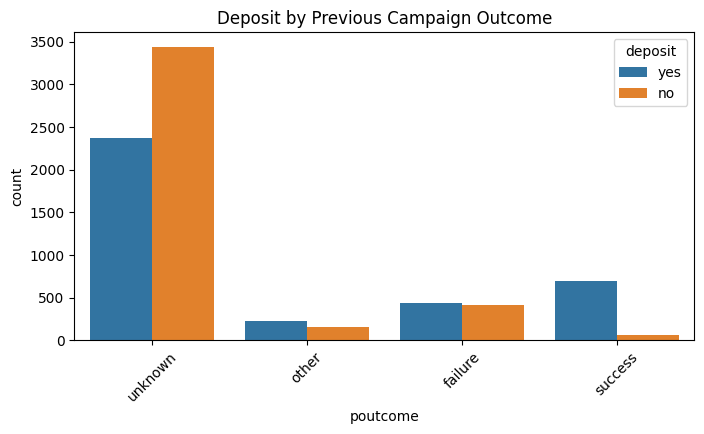

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='poutcome', hue='deposit')
plt.title('Deposit by Previous Campaign Outcome')
plt.xticks(rotation=45)
plt.show()

In [22]:
contingency_table = pd.crosstab(df['poutcome'], df['deposit'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

chi2, p

(np.float64(716.7746048850267), np.float64(4.837357332819864e-155))

**HIPOTESIS:**
<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;">
<ul>
<li>H₀: There is no association between previous campaign outcome (poutcome) and deposit subscription.</li>
<li>H₁: There is an association between previous campaign outcome (poutcome) and deposit subscription.</li>
</ul>
</blockquote>

**Decision**

Since the p-value is less than 0.05, **reject the null hypothesis (H₀)**.

**Interpretation**

There is strong statistical evidence that previous campaign outcome significantly influences deposit subscription. Customers with a successful previous campaign history are more likely to subscribe compared to those with failure or unknown outcomes.

**Balance Distribution vs Deposit**

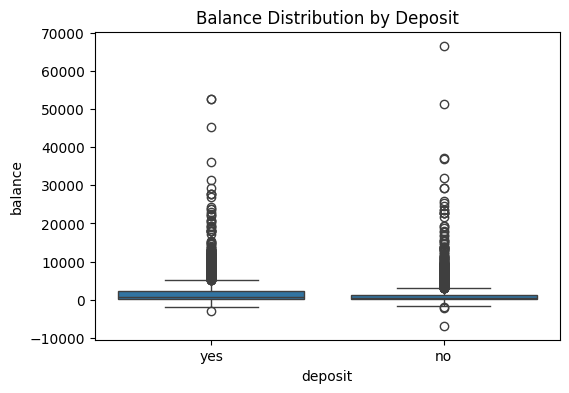

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='deposit', y='balance')
plt.title('Balance Distribution by Deposit')
plt.show()

**HIPOTESIS:**

<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;"> <ul> <li>H₀: The distribution of balance is the same between customers who subscribe and those who do not subscribe.</li> <li>H₁: The distribution of balance differs between customers who subscribe and those who do not subscribe.</li> </ul> </blockquote>

**Decision:**
Since p-value = 1.05 × 10⁻⁴⁹ < 0.05, **reject H₀**.

**Interpretation:**
There is a significant difference in account balance between subscribers and non-subscribers. Customers with higher balances are more likely to subscribe, indicating that financial capacity strongly influences deposit decisions.

**Contact Method vs Deposit**

In [24]:
from scipy.stats import mannwhitneyu

yes_balance = df[df['deposit']=='yes']['balance']
no_balance = df[df['deposit']=='no']['balance']

stat, p = mannwhitneyu(yes_balance, no_balance)

stat, p

(np.float64(9073489.0), np.float64(1.0507020061219825e-49))

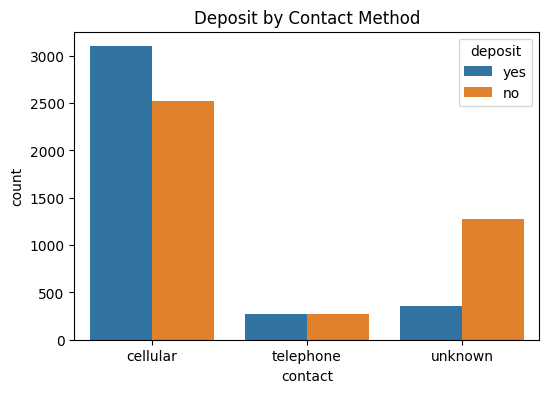

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='contact', hue='deposit')
plt.title('Deposit by Contact Method')
plt.show()

In [26]:
contingency_table = pd.crosstab(df['contact'], df['deposit'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

chi2, p

(np.float64(555.3330704380845), np.float64(2.5760598282823565e-121))

**HIPOTESIS:**

<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;"> <ul> <li>H₀: There is no association between contact method and deposit subscription.</li> <li>H₁: There is an association between contact method and deposit subscription.</li> </ul> </blockquote>

**Decision:**
Since p-value = 2.58 × 10⁻¹²¹ < 0.05, **reject H₀.**

**Interpretation:**
Contact method significantly affects subscription likelihood. Cellular contact shows higher conversion compared to other methods, suggesting that communication channel optimization can improve campaign performance.

**Campaign Frequency vs Deposit**

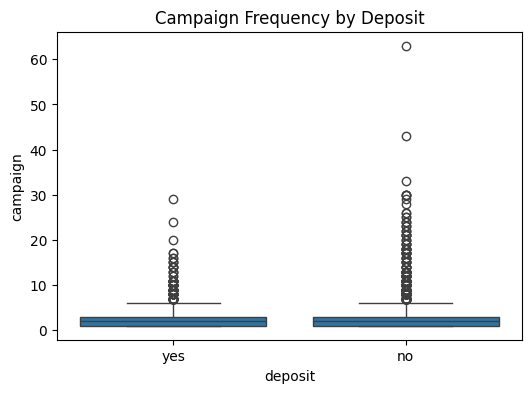

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='deposit', y='campaign')
plt.title('Campaign Frequency by Deposit')
plt.show()

In [28]:
yes_campaign = df[df['deposit']=='yes']['campaign']
no_campaign = df[df['deposit']=='no']['campaign']

stat, p = mannwhitneyu(yes_campaign, no_campaign)

stat, p

(np.float64(6558201.0), np.float64(2.25939132541279e-28))

**HIPOTESIS:**

<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;"> <ul> <li>H₀: The distribution of campaign frequency is the same between subscribers and non subscribers.</li> <li>H₁: The distribution of campaign frequency differs between subscribers and non subscribers.</li> </ul> </blockquote>

**Decision:**
Since p-value = 2.26 × 10⁻²⁸ < 0.05, we reject H₀.

**Interpretation:**
There is a significant difference in campaign frequency between the two groups. Increasing the number of calls does not necessarily increase conversion, indicating diminishing returns from excessive contact attempts.

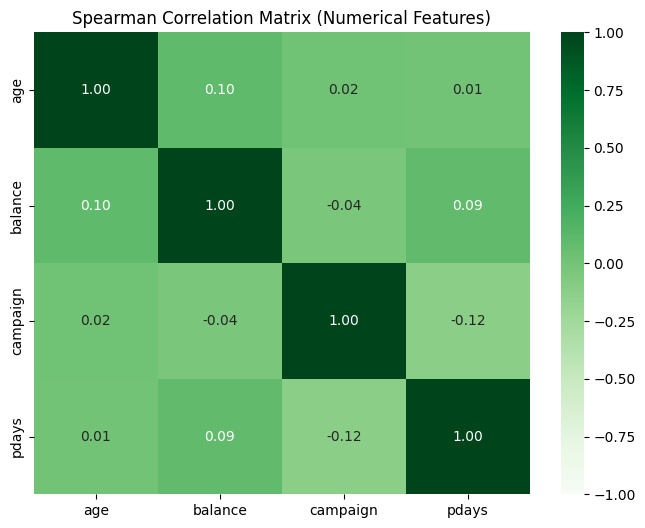

In [29]:
numerical_features = ['age', 'balance', 'campaign', 'pdays']

correlation_matrix = df[numerical_features].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, cmap="Greens", annot=True, vmin=-1, vmax=1, fmt=".2f")
plt.title("Spearman Correlation Matrix (Numerical Features)")
plt.show()

In [30]:
df['deposit_binary'] = df['deposit'].map({'yes':1, 'no':0})

In [31]:
from scipy.stats import spearmanr

correlation_results = {}

for feature in numerical_features:
    correlation, p_value = spearmanr(df[feature], df['deposit_binary'])
    correlation_results[feature] = {
        'Spearman Correlation': correlation,
        'p-value': p_value
    }

correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')
correlation_df

,Spearman Correlation,p-value
age,0.000579,9.592373e-01
balance,0.167787,2.204435e-50
campaign,-0.125054,1.406212e-28
pdays,0.219346,1.161806e-85


| Feature  | Spearman | p-value | Insight                |
| -------- | -------- | ------- | ---------------------- |
| age      | 0.0006   | 0.959   | No relationship        |
| balance  | 0.168    | < 0.001 | Weak positive          |
| campaign | -0.125   | < 0.001 | Weak negative          |
| pdays    | 0.219    | < 0.001 | Weak–moderate positive |


> There is statistically significant monotonic relationship between balance, campaign, pdays and deposit decision. However, the correlation strength is weak, indicating that non-linear models are more suitable for this classification problem.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 6. Feature Engineering

></div>
**** 


In [32]:
# value counts targeted data
df['deposit'].value_counts()/len(df)*100

deposit
no     52.210122
yes    47.789878
Name: count, dtype: float64

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Class Distribution Insight :</b><br>
    <li>The dataset can technically be considered slightly imbalanced. However, the imbalance ratio is relatively small, meaning that the distribution between the two classes (deposit = 0 and deposit = 1) is still fairly comparable. In practical terms, some practitioners may even categorize this dataset as approximately balanced.</li><br>
    <li>Given this mild imbalance, applying resampling techniques is not strictly necessary. Nevertheless, the F1-score is an appropriate evaluation metric in this case, as it balances precision and recall and provides a more reliable performance measure when class distribution is not perfectly equal.</li><br>
    <li>To ensure a robust modeling approach, resampling techniques (such as Random Under Sampling or SMOTE) will still be tested experimentally. This allows us to evaluate whether resampling significantly improves model performance or if it introduces unnecessary bias. The final decision regarding resampling will be based on empirical comparison of evaluation metrics.</li><br>

In [33]:
# unique data

features=[]
nunique=[]
dtype = []

for i in df.columns:
    features.append(i)
    nunique.append(df[i].nunique())
    dtype.append(df[i].dtype)

pd.DataFrame({'features':features,
             'nunique':nunique,
            'dtype':dtype})

,features,nunique,dtype
0,age,75,int64
1,job,12,str
2,balance,3152,int64
3,housing,2,str
4,loan,2,str
5,contact,3,str
6,month,12,str
7,campaign,32,int64
8,pdays,422,int64
9,poutcome,4,str


<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
<li><b>Job</b> : The job column will be encoded using One-Hot Encoding because it contains a relatively small number of categories, and the occupation types do not have any ordinal relationship.</li><br>

<li><b>Housing</b> : The housing column will be encoded using One-Hot Encoding since it consists of binary categories (yes/no), and these categories do not represent an ordinal scale.</li><br>

<li><b>Loan</b> : The loan column will also be encoded using One-Hot Encoding because it contains binary categories (yes/no) that are nominal rather than ordinal.</li><br>

<li><b>Contact</b> : The contact column will be encoded using One-Hot Encoding as it includes categories such as cellular, telephone, and unknown. These categories do not possess any inherent ranking or order.</li><br>

<li><b>Month</b> : The month column will first be analyzed to determine whether it has a linear relationship with the target variable (deposit). If a meaningful ordinal pattern is identified, Ordinal Encoding will be applied. If no ordinal relationship is observed, One-Hot Encoding will be used instead.</li><br>

<li><b>`Poutcome`</b> : The `poutcome` column will be encoded using One-Hot Encoding because its categories (success, failure, unknown, and other) are nominal and do not represent any ordinal hierarchy.</li><br>

<li><b>Deposit (Target Variable)</b> : The deposit column will be converted into binary numerical format (0 and 1) for modeling purposes. Since it contains only two categories (yes/no), it does not require ordinal encoding but rather simple binary transformation.</li><br>

In [34]:
# View the proportion of customers who subscribed or did not subscribe to deposit based on month
data_subscribed = pd.crosstab(index=df['month'], columns=df['deposit'], normalize='index') * 100

list1 = [4,8,12,2,1,7,6,3,5,11,10,9]

data_subscribed.reset_index(inplace=True)
data_subscribed['month_number'] = list1
data_subscribed.drop(columns='month', inplace=True)
data_subscribed = data_subscribed.set_index("month_number").sort_values('month_number')

data_subscribed

deposit,no,yes
month_number,,
1,56.387665,43.612335
2,43.632959,56.367041
3,11.055276,88.944724
4,37.311178,62.688822
5,66.649772,33.350228
6,55.075846,44.924154
7,59.103908,40.896092
8,54.209066,45.790934
9,16.037736,83.962264


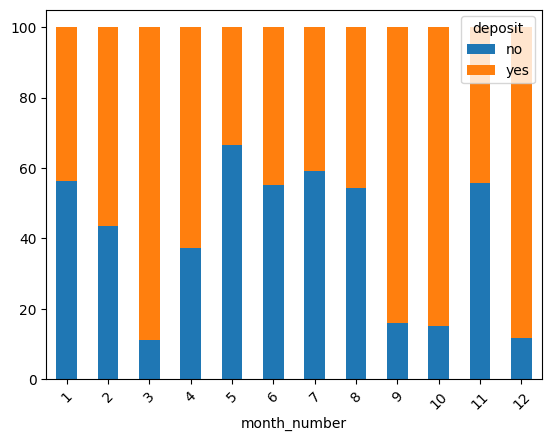

In [35]:
# Visualize the number of customers who subscribed or did not subscribe to deposit by month
data_subscribed.plot(kind='bar', stacked=True)

plt.xticks(rotation=45)
plt.show()

The month variable does not show a clear linear or ordinal relationship with the deposit target. Subscription rates vary across months without forming a consistent trend.

Therefore, the month column will be encoded using One-Hot Encoding, as it should be treated as a nominal feature rather than an ordinal one.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 7. Modelling

></div>
**** 

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.1 Define X, y

></div>
****

In [36]:
X = df.drop(columns=target_col)
y = df[target_col]

display(X.head(), y.head())

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit_binary
0,55,admin.,1662,no,no,cellular,jun,2,0,unknown,1
1,39,self-employed,-3058,yes,yes,cellular,apr,3,0,unknown,1
2,51,admin.,3025,no,no,cellular,may,1,352,other,1
3,38,services,-87,yes,no,cellular,may,1,0,unknown,0
4,36,housemaid,205,yes,no,telephone,nov,4,0,unknown,0


0    yes
1    yes
2    yes
3     no
4     no
Name: deposit, dtype: str

In [37]:
# Separate features and target variable
X = df.drop(columns=['deposit'])
y = np.where(df['deposit'] == 'yes', 1, 0)  # 1 = subscribed, 0 = not subscribed

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.2 Train-Test Split

></div>

****

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.20,
                                                    random_state = 0,
                                                    stratify = y
                                                    )


<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.3 Preprocessing

></div>
****

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 7805 entries, 0 to 7812
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             7805 non-null   int64
 1   job             7805 non-null   str  
 2   balance         7805 non-null   int64
 3   housing         7805 non-null   str  
 4   loan            7805 non-null   str  
 5   contact         7805 non-null   str  
 6   month           7805 non-null   str  
 7   campaign        7805 non-null   int64
 8   pdays           7805 non-null   int64
 9   poutcome        7805 non-null   str  
 10  deposit         7805 non-null   str  
 11  deposit_binary  7805 non-null   int64
dtypes: int64(5), str(7)
memory usage: 792.7 KB


In [40]:

categorical_features = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']
numeric_features = ['age', 'balance', 'campaign', 'pdays']

preprocess = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaler', StandardScaler(), numeric_features)
])

preprocess.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [41]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.4 Model Selection 

></div>

****

- Five models were selected for cross-validation: Decision Tree, Logistic Regression, K-Nearest Neighbors (KNN), Random Forest, and XGBoost. These models were chosen to represent different learning approaches, including linear, distance-based, and ensemble tree-based methods.

- The parameter `random_state`=2020 was added to ensure reproducibility. This guarantees that the randomization process (such as data splitting and model initialization) produces consistent results across different runs.

- The parameter `max_depth`=5 was applied to tree-based models (Decision Tree, Random Forest, and XGBoost) to reduce the risk of overfitting. By limiting the depth of the trees, the models are constrained from becoming overly complex and memorizing noise in the training data.

- the parameter `max_iter`=1000 was set for Logistic Regression to prevent convergence warnings. Increasing the maximum number of iterations allows the optimization algorithm sufficient time to converge during model training.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

tree = DecisionTreeClassifier(max_depth=5,random_state=2020)
logreg = LogisticRegression(random_state=2020, max_iter = 1000)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(max_depth=5,random_state=2020)
xgb = XGBClassifier(max_depth=5,random_state=2020)

In [43]:
# make pipe line

estimator = Pipeline([
    ('preprocess', preprocess),
    ('model', tree)
])

In [44]:
hyperparam_space = {'model':[tree, logreg, knn, rf, xgb]}
skfold = StratifiedKFold(n_splits=5)
grid = GridSearchCV(estimator,
                   param_grid=hyperparam_space,
                    cv=skfold,
                    scoring='f1',
                    n_jobs=-1,
                    error_score='raise'
                   )

In [45]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2020))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model': [DecisionTreeC...om_state=2020), LogisticRegre...om_state=2020), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [46]:
pd.DataFrame(grid.cv_results_)[['mean_fit_time','params','mean_test_score','std_test_score','rank_test_score']]

,mean_fit_time,params,mean_test_score,std_test_score,rank_test_score
0,0.040030,"{'model': DecisionTreeClassifier(max_depth=5, random_state=2020)}",0.585332,0.047958,5
1,0.053133,"{'model': LogisticRegression(max_iter=1000, random_state=2020)}",0.654235,0.020535,2
2,0.027851,{'model': KNeighborsClassifier()},0.639596,0.010763,3
3,0.267235,"{'model': RandomForestClassifier(max_depth=5, random_state=2020)}",0.638332,0.017487,4
4,0.085982,"{'model': XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=5, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...)}",0.670470,0.017692,1


<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>It can be observed that the <b>XGBoost</b> model achieved the highest average evaluation metric among all tested models, followed by Logistic Regression. In addition to their strong performance, both models exhibit relatively low standard deviation values, indicating stable and consistent performance across cross-validation folds.</li><br>
    <li>Therefore, these two models will be further evaluated using the test dataset to assess their generalization performance before selecting the final model for deployment.</li><br>

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.5 Model Performance

></div>

****

In [47]:
#xgboost
bestmodel = grid.best_estimator_
bestmodel.fit(X_train,y_train)
print(classification_report(y_test,bestmodel.predict(X_test)))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       815
           1       0.73      0.61      0.67       746

    accuracy                           0.71      1561
   macro avg       0.71      0.70      0.70      1561
weighted avg       0.71      0.71      0.71      1561



In [48]:
# logreg
logreg = LogisticRegression(random_state=2020, max_iter=1000)
estimator = Pipeline([
    ('preprocess', preprocess),
    ('model', logreg)
])
estimator.fit(X_train,y_train)
print(classification_report(y_test, estimator.predict(X_test)))

              precision    recall  f1-score   support

           0       0.68      0.80      0.73       815
           1       0.73      0.58      0.65       746

    accuracy                           0.70      1561
   macro avg       0.70      0.69      0.69      1561
weighted avg       0.70      0.70      0.69      1561



<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>It can be observed that both models demonstrate similar evaluation metric values (F1-score, precision, and recall) between the cross-validation results and the test set performance. This consistency indicates that neither model is experiencing significant overfitting, as their generalization performance remains stable on unseen data.</li><br>
    <li>Therefore, both XGBoost and Logistic Regression will proceed to the hyperparameter tuning stage in order to further optimize their performance and identify the best-performing configuration..</li><br>

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.6 Re-Sampling

></div>

****

In [49]:
# without resample
logreg = LogisticRegression(random_state=2020, max_iter=1000)
model_basic = Pipeline([
    ('preprocess', preprocess),
    ('model', logreg)
])
model_basic.fit(X_train,y_train)
y_pred_basic = model_basic.predict(X_test)
print(classification_report(y_test, y_pred_basic))

              precision    recall  f1-score   support

           0       0.68      0.80      0.73       815
           1       0.73      0.58      0.65       746

    accuracy                           0.70      1561
   macro avg       0.70      0.69      0.69      1561
weighted avg       0.70      0.70      0.69      1561



In [50]:
# resampling random over sampling
rus = RandomUnderSampler(random_state=2022)
model_rus = Pipeline([
    ('preprocess', preprocess),
    ('resampling', rus),
    ('model', logreg)
])
model_rus.fit(X_train,y_train)
y_pred_rus = model_rus.predict(X_test)
print(classification_report(y_test, y_pred_rus))

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       815
           1       0.70      0.61      0.65       746

    accuracy                           0.69      1561
   macro avg       0.69      0.69      0.69      1561
weighted avg       0.69      0.69      0.69      1561



In [51]:
#resampling SMOTE
smote = SMOTE(random_state = 2020)
model_smote = Pipeline([
    ('preprocess', preprocess),
    ('resampling', smote),
    ('model', logreg)
])
model_smote.fit(X_train,y_train)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       815
           1       0.70      0.62      0.66       746

    accuracy                           0.69      1561
   macro avg       0.69      0.69      0.69      1561
weighted avg       0.69      0.69      0.69      1561



<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>IIt can be observed that the application of resampling techniques (Random Under Sampling and SMOTE) does not significantly improve the evaluation metrics, including precision, recall, and F1-score. The performance differences before and after resampling are minimal</li><br>
    <li>Given that the dataset is only slightly imbalanced, resampling does not provide substantial benefits in this case. Instead, it may introduce unnecessary bias by artificially altering the original class distribution</li><br>
    <li>Therefore, resampling is not recommended for this dataset, as it does not meaningfully enhance model performance and may reduce the reliability of the evaluation results.</li><br>

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 7.7 TUNNING

></div>

**** 

### **Logistic Regression**

> First, we will perform hyperparameter tuning on the second-ranked model from the cross-validation stage, namely Logistic Regression, in order to optimize its performance and identify the best parameter configuration before comparing it with the top-ranked model.

In [52]:
model_basic.get_params()

{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(transformers=[('onehot',
                                    OneHotEncoder(drop='first',
                                                  handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['job', 'housing', 'loan', 'contact', 'month',
                                     'poutcome']),
                                   ('scaler', StandardScaler(),
                                    ['age', 'balance', 'campaign', 'pdays'])])),
  ('model', LogisticRegression(max_iter=1000, random_state=2020))],
 'transform_input': None,
 'verbose': False,
 'preprocess': ColumnTransformer(transformers=[('onehot',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore',
                                                sparse_output=False),
                                  ['job', 'ho

In [53]:
# changing parameter 
hyperparam_space={'model__C':[100,10,1,0.1,0.001],
                 'model__solver':['liblinear','newton-cg', 'lbfgs'],
                 'model__max_iter':[1000,10000]}

It can be observed that the parameters to be optimized include 

- C (regularization strength)

- solver (optimization algorithm)

- and max_iter (maximum number of iterations)

In [54]:
# grisearch logreg model
grid_logreg = GridSearchCV(model_basic,
                   param_grid=hyperparam_space,
                   cv=skfold,
                   scoring='f1',
                   n_jobs=-1)

In [55]:
# Train data logreg
grid_logreg.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2020))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [100, 10, ...], 'model__max_iter': [1000, 10000], 'model__solver': ['liblinear', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [56]:
# Display the best hyperparameters and the best cross-validation score
grid_logreg.best_params_, grid_logreg.best_score_

({'model__C': 0.1, 'model__max_iter': 1000, 'model__solver': 'newton-cg'},
 np.float64(0.6613539612318552))

In [57]:
# Test the model with the best hyperparameters on the test dataset
model_logreg_hyper = grid_logreg.best_estimator_

model_logreg_hyper.fit(X_train, y_train)

print(classification_report(y_test, model_logreg_hyper.predict(X_test)))

              precision    recall  f1-score   support

           0       0.68      0.79      0.73       815
           1       0.72      0.60      0.65       746

    accuracy                           0.69      1561
   macro avg       0.70      0.69      0.69      1561
weighted avg       0.70      0.69      0.69      1561



<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>It can be observed that the Logistic Regression model with the best hyperparameters (C = 0.1, max_iter = 100, solver = liblinear) achieved an F1-score of 65% on the test dataset.</li><br>
    <li>Next, we will compare this result with the top-ranked model from the cross validation stage after performing hyperparameter tuning, in order to determine which model delivers better overall performance</li><br>

***

### **XGboost**

> Next, we will perform hyperparameter tuning on the top-ranked model from the cross-validation stage, namely XGBoost, in order to further **optimize its performance** and determine whether it can achieve better generalization results on the test dataset.

In [58]:
# Check which parameters can be tuned
bestmodel.get_params()

{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(transformers=[('onehot',
                                    OneHotEncoder(drop='first',
                                                  handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['job', 'housing', 'loan', 'contact', 'month',
                                     'poutcome']),
                                   ('scaler', StandardScaler(),
                                    ['age', 'balance', 'campaign', 'pdays'])])),
  ('model',
   XGBClassifier(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bynode=None,
                 colsample_bytree=None, device=None, early_stopping_rounds=None,
                 enable_categorical=False, eval_metric=None, feature_types=None,
                 feature_weights=None, gamma=None, grow_policy=None,
                 importance_type=None, interaction

In [59]:
# Define the hyperparameter combinations to be tested
hyperparam_space = [
    {'model__learning_rate': [0.1],  'model__n_estimators': [200],  'model__max_depth': [3, 4, 5]}, 
    {'model__learning_rate': [0.05], 'model__n_estimators': [400],  'model__max_depth': [3, 4, 5]}, 
    {'model__learning_rate': [0.005],'model__n_estimators': [4000], 'model__max_depth': [3, 4, 5]} 
]

The hyperparameters to be optimized include learning rate (step size weight), n_estimators (number of boosting iterations), and max_depth (tree depth).

- Learning rate controls how much each new tree contributes to the overall model.

- n_estimators represents the number of boosting rounds or trees built sequentially.

- Max depth determines the maximum depth of each tree, which affects model complexity and the risk of overfitting.

These parameters are tuned to achieve the best balance between model performance and generalization ability.

In [60]:
#gridsearch model xgb
xgb = XGBClassifier(max_depth=5,random_state=2020)
estimator = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb)
])
grid_xgb = GridSearchCV(estimator,
                   param_grid=hyperparam_space,
                   cv=skfold,
                   scoring='f1',
                   n_jobs=-1)


In [61]:
grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__learning_rate': [0.1], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [200]}, {'model__learning_rate': [0.05], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [400]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intCon

In [62]:
#best parameter best score
grid_xgb.best_params_, grid_xgb.best_score_

({'model__learning_rate': 0.05,
  'model__max_depth': 3,
  'model__n_estimators': 400},
 np.float64(0.6807947479592308))

In [63]:
# Evaluate the XGBoost model with the best hyperparameters on the test dataset
model_xgb_hyper = grid_xgb.best_estimator_

model_xgb_hyper.fit(X_train, y_train)

print(classification_report(y_test, model_xgb_hyper.predict(X_test)))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       815
           1       0.76      0.60      0.67       746

    accuracy                           0.72      1561
   macro avg       0.73      0.71      0.71      1561
weighted avg       0.73      0.72      0.72      1561



<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight :</b><br>
    <li>The model achieved an overall accuracy of 72% on the test dataset.</li><br>
    <li>For customers who did not subscribe (Class 0), the model shows strong recall (82%), meaning it correctly identifies most non-subscribers.</li><br>
    <li>For customers who subscribed (Class 1), the model achieved precision of 76% and recall of 60%, indicating that while predictions of subscribers are fairly accurate, the model still misses some potential depositors.</li><br>
    <li>Overall, the performance is balanced, but recall for subscribers could be improved if the business priority is to reduce missed opportunities.</li><br>

***

### **LogReg After Tunning vs XGBoost After Tunning**

In [64]:
# Compare Logistic Regression and XGBoost after hyperparameter tuning

print('Logistic Regression after tuning')
model_logreg_hyper = grid_logreg.best_estimator_
model_logreg_hyper.fit(X_train, y_train)
print(classification_report(y_test, model_logreg_hyper.predict(X_test)))

print('XGBoost after tuning')
model_xgb_hyper = grid_xgb.best_estimator_
model_xgb_hyper.fit(X_train, y_train)
print(classification_report(y_test, model_xgb_hyper.predict(X_test)))

Logistic Regression after tuning
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       815
           1       0.72      0.60      0.65       746

    accuracy                           0.69      1561
   macro avg       0.70      0.69      0.69      1561
weighted avg       0.70      0.69      0.69      1561

XGBoost after tuning
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       815
           1       0.76      0.60      0.67       746

    accuracy                           0.72      1561
   macro avg       0.73      0.71      0.71      1561
weighted avg       0.73      0.72      0.72      1561





>- After comparing both models, the tuned XGBoost performs better than the tuned Logistic Regression in terms of evaluation metrics.

>- Therefore, the tuned XGBoost model is selected as the final model for prediction.

**Performance difference between XGBoost before and after tuning:**

In [65]:
# Compare XGBoost performance before and after hyperparameter tuning

print('XGBoost before tuning')
xgb = XGBClassifier(max_depth=5, random_state=2020)

xgb_model = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb)
])

xgb_model.fit(X_train, y_train)
print(classification_report(y_test, xgb_model.predict(X_test)))

print('XGBoost after tuning')
model_xgb_hyper = grid_xgb.best_estimator_
model_xgb_hyper.fit(X_train, y_train)
print(classification_report(y_test, model_xgb_hyper.predict(X_test)))

XGBoost before tuning
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       815
           1       0.73      0.61      0.67       746

    accuracy                           0.71      1561
   macro avg       0.71      0.70      0.70      1561
weighted avg       0.71      0.71      0.71      1561

XGBoost after tuning
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       815
           1       0.76      0.60      0.67       746

    accuracy                           0.72      1561
   macro avg       0.73      0.71      0.71      1561
weighted avg       0.73      0.72      0.72      1561



>After performing hyperparameter tuning, the model’s evaluation metrics show an improvement, although the increase is not significant.

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Result : the tuned XGBoost model is selected as the final model to address the business problem.</b><br>


    

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
             
# 8. Model Evaluation & Business Impact
></div>
****

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 8.1 FINAL MODEL

></div>


**** 

In [66]:
preprocessor = model_xgb_hyper.named_steps['preprocess']

In [67]:
feature_names = preprocessor.get_feature_names_out()

# REMOVE prefix seperti 'onehot__' atau 'scaler__'
clean_feature_names = [name.split('__')[-1] for name in feature_names]

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight</b>
    <li>The most influential feature is poutcome_success, indicating that customers who previously responded positively to a campaign are significantly more likely to subscribe again..</li><br>
    <li>Financial status factors such as housing loan ownership and personal loan status also play an important role, suggesting that customers’ financial commitments influence deposit decisions.</li><br>
    <li>Additionally, certain months (e.g., March, June, October, September) show meaningful impact, indicating potential seasonal effects in customer behavior.</li><br>
    <li>Overall, past campaign success is the strongest predictor, followed by financial profile and timing factors.</li><br>


In [68]:
# Final model selected to address the business problem
model_xgb_hyper = grid_xgb.best_estimator_
model_xgb_hyper.fit(X_train, y_train)
print(classification_report(y_test, model_xgb_hyper.predict(X_test)))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       815
           1       0.76      0.60      0.67       746

    accuracy                           0.72      1561
   macro avg       0.73      0.71      0.71      1561
weighted avg       0.73      0.72      0.72      1561



<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
 <b>The model with the best evaluation metrics is the tuned XGBoost model</b>
 
>
> XGBoost is a tree based algorithm built on the boosting framework, where multiple decision trees are created sequentially to improve prediction performance by correcting previous errors. Its additional optimization techniques make it more powerful and robust compared to standard boosting methods.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 8.2 Confussion Matrix Analysis

></div>

**** 

>The confusion matrix provides a detailed breakdown of the model’s prediction results and the types of errors it makes. Each cell in the matrix represents the combination of predicted outcomes and actual outcomes, allowing us to clearly identify correct predictions as well as misclassifications.
>
>Through the confusion matrix, we can analyze True Positives, True Negatives, False Positives, and False Negatives, which are essential for understanding the practical impact of the model’s performance in a business context.

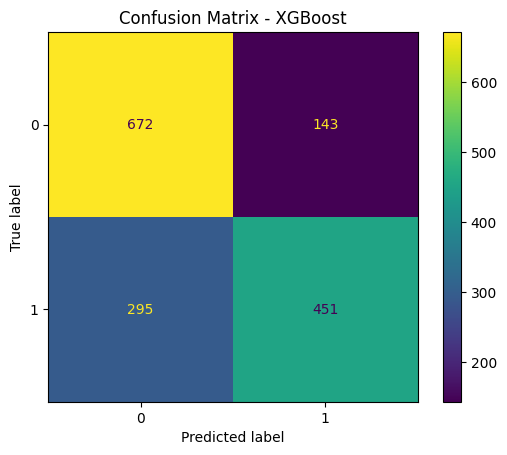

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model_xgb_hyper,
    X_test,
    y_test
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

**RESULT :**

**- True Positive (451) :**
Customers correctly identified as potential subscribers. These are ideal targets for the campaign.

**- True Negative (672) :**
Customers correctly identified as not likely to subscribe. This helps avoid unnecessary telemarketing costs.

**- False Positive (143) :**
Customers predicted as potential subscribers but who did not subscribe. These represent wasted telemarketing effort and operational cost.

**- False Negative (295) :**
Customers who were actually potential subscribers but were not identified by the model. These represent lost revenue opportunities.

<blockquote style="background: #F5EFE7; padding: 10px; border-left: 4px solid #D8C4B6; margin: 10px 0;">
    <b>Insight : </b>
    <li>The confusion matrix shows that the model correctly classified 672 customers as not subscribing (True Negative) and 451 customers as subscribing (True Positive)</li><br>
    <li>However, the model incorrectly predicted 143 customers as subscribing when they did not (False Positive) and missed 295 potential subscribers (False Negative)..</li><br>
    <li>Indicates that while the model performs reasonably well overall, there is still a moderate number of missed potential customers, which may impact business opportunities..</li><br>








<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 8.3 Feature Importance & Model Interpretation

></div>

**** 

In [70]:
# Retrieve trained model
best_model = model_xgb_hyper

# Get preprocess step
preprocessor = best_model.named_steps['preprocess']

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Clean feature names (remove prefix)
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# Get feature importance
feature_importances = best_model.named_steps['model'].feature_importances_

# Create dataframe
import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(15)

,Feature,Importance
27,poutcome_success,0.260547
11,housing_yes,0.101564
14,contact_unknown,0.088876
21,month_mar,0.074061
20,month_jun,0.068243
24,month_oct,0.050161
25,month_sep,0.047485
12,loan_yes,0.039723
7,job_student,0.020021
32,pdays,0.018364


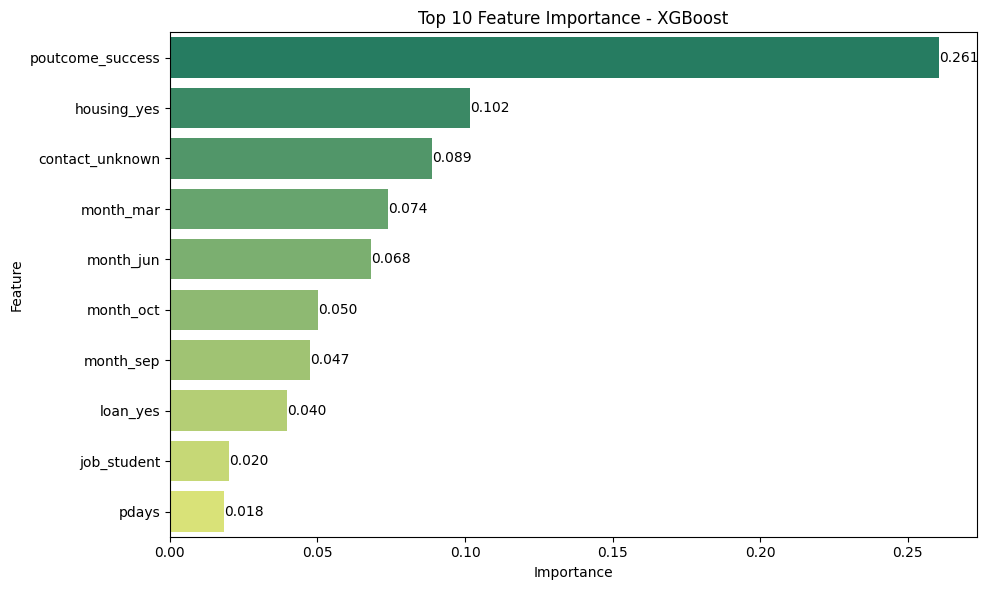

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
    palette='summer'
)

plt.title('Top 10 Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')

for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                va='center',
                ha='left')

plt.tight_layout()
plt.show()

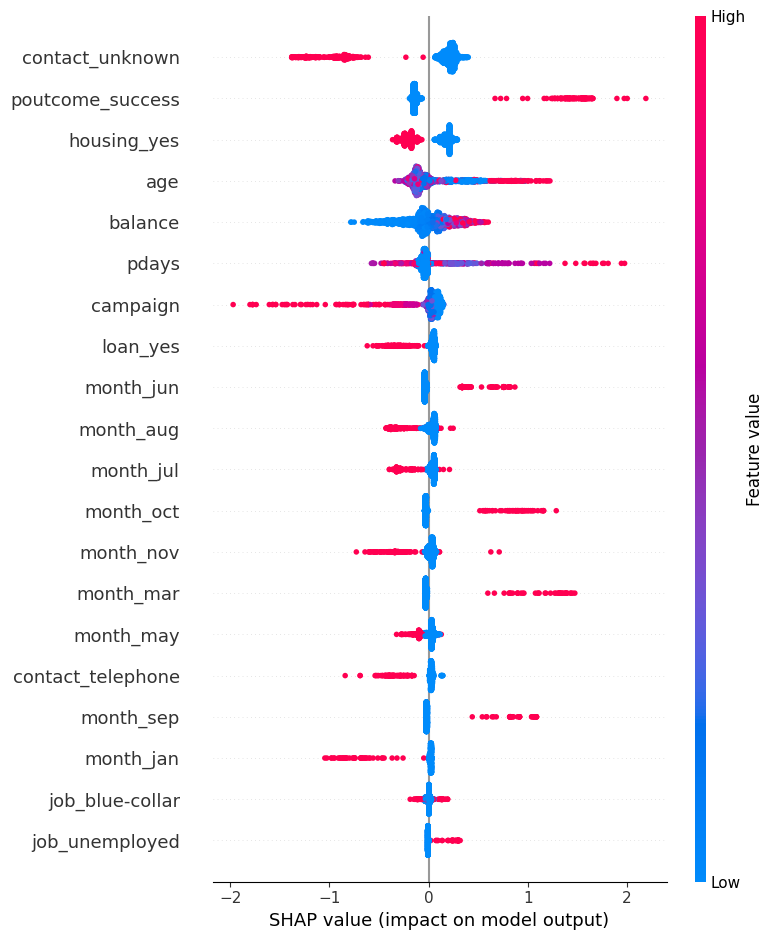

In [72]:
import shap

# Retrieve final pipeline
best_model = model_xgb_hyper

# Get preprocessor and trained model
preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']

# Transform test data (without fitting again)
X_test_transformed = preprocessor.transform(X_test)

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Retrieve feature names
feature_names = preprocessor.get_feature_names_out()

# Remove prefixes such as 'onehot__' or 'scaler__'
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# SHAP summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=clean_feature_names)

>**Trend**: `poutcome_success` has the strongest positive SHAP values. When the previous campaign was successful, the model prediction increases significantly.
>
>Insight: Past campaign success is the most powerful predictor. Customers who subscribed before are highly likely to subscribe again.

>**Trend**: Higher `balance` values push SHAP values positively.
>
>Insight: Customers with higher account balances are more likely to subscribe to a deposit product.

>**Trend**: Higher `campaign` values (more contact attempts) tend to push SHAP values negatively.
>
>Insight: Excessive contact attempts may reduce the likelihood of subscription, indicating diminishing returns from repeated calls.

>**Trend**: Certain `months` (e.g : March, June, October) show positive SHAP effects.
>
>Insight: There is a seasonal pattern, meaning timing plays an important role in campaign effectiveness.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #557ab6ff;
            overflow:hidden;
            font-weight:500"
            

## 8.4 Cost Evaluation

></div>

**** 
Cost per call (10 minutes × $0.10) = $1 per customer

Profit per successful deposit = $10

From confusion matrix:

|                     | **Predicted: No (0)** | **Predicted: Yes (1)** |
| ------------------- | --------------------- | ---------------------- |
| **Actual: No (0)**  | **TN = 672**          | **FP = 143**           |
| **Actual: Yes (1)** | **FN = 295**          | **TP = 451**           |

##### **1. Scenario Before Model**

Without using the predictive model, the bank must contact all 1,952 customers.

Assumptions:

| Component    | Formula         | Value      |
| ------------ | --------------- | ---------- |
| Calling Cost | 1,952 × $1      | **$1,952** |
| Revenue      | 933 × $10       | **$9,330** |
| Net Profit   | $9,330 − $1,952 | **$7,378** |


In this scenario, the company spends 325.3 hours and generates a net profit of $7,378.

#### **2. Scenario After Model**


**Cost Calculation**

| Component                         | Formula                | Value                       |
| --------------------------------- | ---------------------- | --------------------------- |
| Calling Cost (Predicted Positive) | (TP + FP) × $1         | (451 + 143) × $1 = **$594** |
| Revenue from Correct Predictions  | TP × $10               | 451 × $10 = **$4,510**      |
| Lost Revenue (Missed Customers)   | FN × $10               | 295 × $10 = **$2,950**      |
| Wasted Cost (Wrong Target)        | FP × $1                | 143 × $1 = **$143**         |
| Net Profit (Model)                | Revenue − Calling Cost | $4,510 − $594 = **$3,916**  |


Although the direct net profit appears lower, the operational time is reduced significantly:

| Metric                         | Without Model | With Model             |
| ------------------------------ | ------------- | ---------------------- |
| Total Calling Time             | 325.3 hours   | 99 hours               |
| Net Profit (1 Cycle)           | $7,378        | $3,916                 |
| Operational Efficiency         | –             | **3.3x faster**        |
| Profit Within Same 325.3 Hours | $7,378        | **$11,748 (3 cycles)** |


This means the company can run nearly 3 campaign cycles within the same time frame.

- Time reduction factor = 325.3 / 99 ≈ 3.3 times more efficient

- In the same total operational time, the company can run approximately 3 campaign cycles

- Estimated profit in equal time = 3 × $3,916 = $11,748

#### **3. Cost Evaluation Comparison**

| Component                          | Without Model | With Model       |
| ---------------------------------- | ------------- | ---------------- |
| Customers Contacted                | 1,952         | 594              |
| True Positives (Revenue Generated) | 933           | 451              |
| False Positives (Wasted Calls)     | –             | 143              |
| False Negatives (Missed Customers) | –             | 295              |
| Cost per Call                      | $1            | $1               |
| Total Calling Cost                 | $1,952        | $594             |
| Total Revenue                      | $9,330        | $4,510           |
| Net Profit (Single Cycle)          | **$7,378**    | **$3,916**       |
| Total Calling Time                 | 325.3 hours   | 99 hours         |
| Time Efficiency                    | –             | **~3.3× faster** |


#### **4. Equal Time Profit Comparison**
| Scenario              | Profit Within 325.3 Hours |
| --------------------- | ------------------------- |
| Without Model         | $7,378                    |
| With Model (3 Cycles) | **$11,748**               |


**INSIGHT :**
<blockquote style="background: #CDDDF6; padding: 10px; border-left: 4px solid #A6C5F2; margin: 10px 0;">
<ul>
<li>Although the net profit per single campaign cycle is lower when using the model, the significant reduction in operational time allows the bank to run multiple campaign cycles within the same timeframe.</li><li> When time efficiency is considered, the model driven strategy generates higher overall profit and improves resource utilization.</li>
</ul>
</blockquote>



<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 9. Overview

></div>
****

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #3E5879;
            overflow:hidden;
            font-weight:500">Model Performance Overview</div>

>- The tuned **XGBoost model** achieved the highest evaluation metrics among all tested models.
>- The F1-score indicates a good balance between precision and recall in identifying customers likely to subscribe.
>- The model demonstrates stable generalization performance on unseen test data.
>- Overall accuracy confirms that the model correctly classifies the majority of customers.
>
>These results suggest that the model performs reliably in predicting potential deposit subscriptions.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #3E5879;
            overflow:hidden;
            font-weight:500">Model Accuracy and Predictions</div>

>- The model is particularly strong in identifying customers with a successful previous campaign outcome.
>- Predicted probabilities allow customer segmentation based on subscription likelihood.
>- By applying an appropriate probability threshold, the bank can reduce telemarketing costs by focusing on high-potential customers.
>

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #3E5879;
            overflow:hidden;
            font-weight:500">Key Insights from the Data</div>

>- Previous campaign success (poutcome_success) is the most influential factor in predicting subscription.
>- Account balance positively impacts the likelihood of deposit subscription.
>- A high number of campaign contacts may reduce subscription probability, indicating diminishing returns from repeated calls.
>- Certain months show higher impact, suggesting a seasonal effect in customer behavior.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #3E5879;
            overflow:hidden;
            font-weight:500">Model Selection Conclusion</div>

>- The final selected model is the tuned **XGBoost**, as it achieved the best overall performance and stability.
>- XGBoost effectively captures non-linear relationships and interactions between variables.
>- Therefore, this model is chosen to address the business problem of predicting customers likely to subscribe to a deposit product.

<div style="padding:3px; 
            color:#ffff;
            margin:10px;
            font-size:100%;
            text-align:LEFT;
            display:fill;
            background-color: #3E5879;
            overflow:hidden;
            font-weight:500">Areas for Improvement</div>


>- The model may still miss some potential subscribers (false negatives).
>- Threshold tuning can be performed to improve recall if maximizing conversion opportunities is the primary objective.
>- Incorporating additional behavioral or transactional features may further enhance model performance.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 10. Recomendations

></div>
****

<div style="padding:3px; color:#ffff; margin:10px; font-size:100%; text-align:LEFT; display:fill; background-color: #3E5879; overflow:hidden; font-weight:500">For Marketing Campaign Model & Business Impact</div>

**1. Prioritise High-Probability Customers for Targeted Campaigns**

>The predictive model identifies customers with a high probability of subscribing to term deposits. Rather than contacting the entire customer base, the bank can focus only on customers predicted as likely subscribers.
>
>- 1. Suggestion: Use the model’s predicted probabilities to create priority tiers (e.g., high, medium, low probability). Focus telemarketing efforts primarily on high-probability segments.
>- 2. Why: This strategy reduces operational costs, shortens campaign duration, and increases conversion efficiency. It also enables multiple campaign cycles within the same time frame.

**2. Optimise Campaign Strategy Based on Key Predictive Features**

>The model indicates that previous campaign success, account balance, and campaign frequency significantly influence subscription likelihood.
>
> 1. Suggestion:
>
>- Prioritise customers with successful previous campaign outcomes.
>- Target customers with higher account balances.
>- Limit excessive follow-up calls to avoid diminishing returns.
>
>- 2. Why: Repeated contact attempts may reduce customer responsiveness, while customers with positive campaign history and stronger financial profiles are more likely to convert.

**3. Implement Threshold Tuning Based on Business Objectives**
>
>The confusion matrix shows that false negatives represent missed revenue opportunities, while false positives represent operational cost.
>
> 1. Suggestion: Adjust the probability threshold depending on the campaign goal:
>- Lower threshold → increase recall (capture more potential subscribers).
>- Higher threshold → increase precision (reduce unnecessary calls).
>
> 2. Why: Aligning the threshold with business priorities ensures that model deployment supports either revenue maximisation or cost efficiency.

**4. Improve Data Quality and Enrich Features**
> Some features, such as unknown contact status, negatively impact predictions.
>
> 1. Suggestion:
>
>- Improve data collection processes to reduce missing or unknown values.
>
>- Consider incorporating additional behavioural data (e.g., transaction frequency, product ownership, tenure).
>
> 2. Why: Better data quality and richer features can improve prediction accuracy and overall campaign effectiveness.
>

<div style="padding:3px; color:#ffff; margin:10px; font-size:100%; text-align:LEFT; display:fill; background-color: #3E5879; overflow:hidden; font-weight:500">For Stakeholders</div>

**1. Marketing Team:** Use predicted probabilities to prioritise high-potential customers and optimise telemarketing resource allocation.

**2. Sales & Telemarketing:** Focus efforts on customers with prior successful interactions and strong financial profiles to improve conversion rates.

**3. Product Management:** Develop targeted deposit offerings tailored to customer segments identified as high-value prospects.

**4. Business Management:** Leverage model insights to improve strategic planning, reduce operational costs, and maximise campaign profitability.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 11. Conclussion

></div>
****

>- Based on the overall evaluation, the tuned XGBoost model was selected as the final model because it achieved the best performance in terms of F1-score and demonstrated stable generalization on unseen data.
>
>- From a business perspective, the model significantly reduces operational costs and telemarketing time by targeting only high-potential customers instead of contacting the entire customer base. Although the net profit per single campaign cycle is lower compared to contacting all customers, the substantial reduction in operational time allows multiple campaign cycles to be executed within the same timeframe.
>
>- When efficiency is considered, the model-driven strategy generates higher overall profit and improves resource utilization. Therefore, implementing the predictive model provides both operational and financial advantages in optimizing the bank’s marketing campaign.

<div style="padding:10px; 
            color:#ffff;
            margin:10px;
            font-size:180%;
            text-align:center;
            display:fill;
            background-color: #213555;
            overflow:hidden;
            font-weight:500"
            

# 12. Saving Model

></div>
****

In [73]:
#all data fit model 
pipe_best = grid_xgb.best_estimator_
pipe_best.fit(X,y)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

In [74]:
import pickle
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model final
with open(f'model_xgb_{timestamp}.pkl', 'wb') as f:
    pickle.dump(pipe_best, f)

# Save model structure as text
as_text_model = str(pipe_best)

with open(f'model_xgb_structure_{timestamp}.txt', 'w') as f:
    f.write(as_text_model)